# DPT Holes

Small notebook to look at different mounting solutions for the DPT holes. 

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union


## Clover pattern

Original circle radius R: 1.000000
Clover circle radius:     0.900000
Center distance a:        0.744949
Pairwise center spacing:  1.290289

Inner cusp radii:
0.25505102572168215
0.2550510257216819
0.25505102572168226

Maximum outward distance from original circle: 0.644948
Occurs at angle: 329.99 degrees


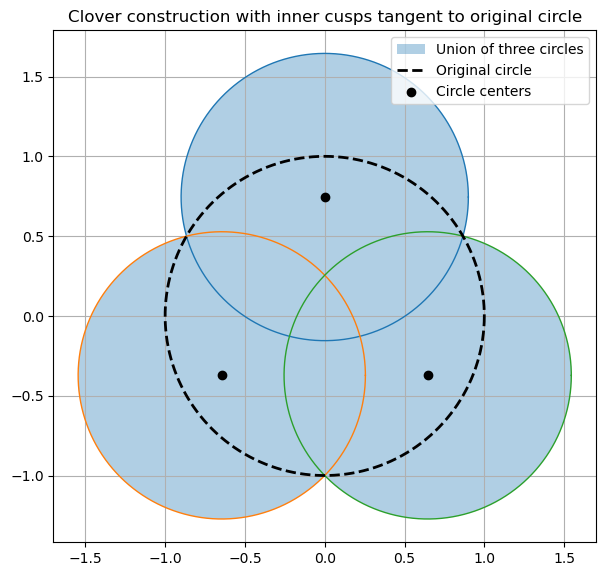

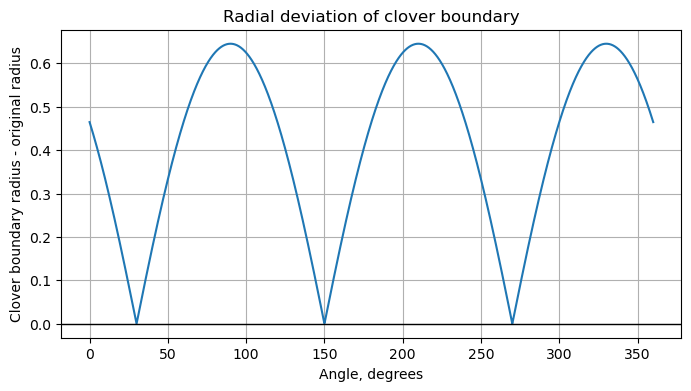


Area Results
----------------------------------------
Original circle area : 3.14158773
Clover union area    : 6.42227425
Difference           : 3.28068652
Percent difference   : 104.4277%


In [13]:

R = 1.0                 # radius of original circle
circle_radius = 0.9     # radius of each of the three clover circles
resolution = 512

# -----------------------------
# GEOMETRY
# -----------------------------
# Three equal circles have centers on an equilateral triangle.
# The inner cusps are the inner pairwise intersections.
#
# We place the centers so that those three inner cusps lie on
# the original circle of radius R.
#
# There is one free parameter: the radius of the three clover circles.

if circle_radius <= np.sqrt(3) * R / 2:
    raise ValueError("circle_radius must be larger than sqrt(3)*R/2")

# Center distance from origin.
# This is the branch that gives a central clover-shaped void.
a = 0.5 * (R + np.sqrt(4 * circle_radius**2 - 3 * R**2))

# Centers of the three equal circles
angles = np.deg2rad([90, 210, 330])

centers = np.column_stack([
    a * np.cos(angles),
    a * np.sin(angles)
])

# Build disks
disks = [
    Point(x, y).buffer(circle_radius, resolution=resolution)
    for x, y in centers
]

clover = unary_union(disks)
original = Point(0, 0).buffer(R, resolution=resolution)

print(f"Original circle radius R: {R:.6f}")
print(f"Clover circle radius:     {circle_radius:.6f}")
print(f"Center distance a:        {a:.6f}")
print(f"Pairwise center spacing:  {np.sqrt(3)*a:.6f}")

# -----------------------------
# COMPUTE INNER CUSP POINTS
# -----------------------------

def circle_intersections(c1, c2, r):
    c1 = np.array(c1)
    c2 = np.array(c2)

    v = c2 - c1
    d = np.linalg.norm(v)

    midpoint = 0.5 * (c1 + c2)
    h = np.sqrt(r**2 - (d / 2)**2)

    u = v / d
    n = np.array([-u[1], u[0]])

    p1 = midpoint + h * n
    p2 = midpoint - h * n

    return p1, p2

cusps = []

for i, j in [(0, 1), (1, 2), (2, 0)]:
    p1, p2 = circle_intersections(
        centers[i],
        centers[j],
        circle_radius
    )

    # inner cusp is the intersection closer to the origin
    cusp = p1 if np.linalg.norm(p1) < np.linalg.norm(p2) else p2
    cusps.append(cusp)

cusps = np.array(cusps)

print()
print("Inner cusp radii:")
for p in cusps:
    print(np.linalg.norm(p))

# -----------------------------
# MAXIMUM OUTWARD RADIAL DISTANCE
# -----------------------------

theta = np.linspace(0, 2*np.pi, 3000)

radial_distance = []

for t in theta:
    direction = np.array([np.cos(t), np.sin(t)])

    lo = 0.0
    hi = a + circle_radius + R

    for _ in range(60):
        mid = 0.5 * (lo + hi)
        p = Point(*(mid * direction))

        if clover.contains(p):
            lo = mid
        else:
            hi = mid

    radial_distance.append(lo - R)

radial_distance = np.array(radial_distance)

max_distance = np.max(radial_distance)
max_angle = theta[np.argmax(radial_distance)]

print()
print(f"Maximum outward distance from original circle: {max_distance:.6f}")
print(f"Occurs at angle: {np.degrees(max_angle):.2f} degrees")

# -----------------------------
# PLOT GEOMETRY
# -----------------------------

fig, ax = plt.subplots(figsize=(7, 7))

# Clover union
x, y = clover.exterior.xy
ax.fill(x, y, alpha=0.35, label="Union of three circles")

# Individual circles
for disk in disks:
    x, y = disk.exterior.xy
    ax.plot(x, y, lw=1)

# Original circle
x, y = original.exterior.xy
ax.plot(x, y, "k--", lw=2, label="Original circle")

# Centers
ax.scatter(centers[:, 0], centers[:, 1], color="black", zorder=5, label="Circle centers")

ax.set_aspect("equal")
ax.set_title("Clover construction with inner cusps tangent to original circle")
ax.legend()
ax.grid(True)

plt.show()

# -----------------------------
# PLOT RADIAL DEVIATION
# -----------------------------

plt.figure(figsize=(8, 4))

plt.plot(np.degrees(theta), radial_distance)
plt.axhline(0, color="black", lw=1)

plt.xlabel("Angle, degrees")
plt.ylabel("Clover boundary radius - original radius")
plt.title("Radial deviation of clover boundary")
plt.grid(True)

plt.show()

# -----------------------------
# AREA CALCULATIONS
# -----------------------------

clover_area = clover.area
original_area = original.area

area_difference = clover_area - original_area
percent_difference = 100 * area_difference / original_area

print("\nArea Results")
print("-" * 40)
print(f"Original circle area : {original_area:.8f}")
print(f"Clover union area    : {clover_area:.8f}")
print(f"Difference           : {area_difference:.8f}")
print(f"Percent difference   : {percent_difference:.4f}%")

## Triangle Pattern

Area Results
----------------------------------------
Circle radius              : 1.00000000
Fillet radius              : 0.80000000
Triangle side length       : 3.46410162
Circle area                : 3.14158773
Filleted triangle area     : 3.88123102
Area difference            : 0.73964329
Percent difference         : 23.5436%


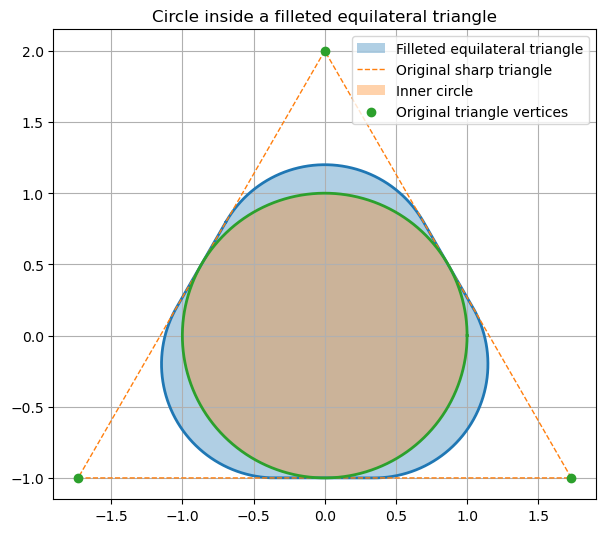

In [18]:

circle_radius = 1.0     # radius of the inner circle
fillet_radius = 0.8    # radius used to round / fillet each triangle point
resolution = 512        # curve smoothness

# -----------------------------
# VALIDATION
# -----------------------------

if circle_radius <= 0:
    raise ValueError("circle_radius must be positive.")

if fillet_radius < 0:
    raise ValueError("fillet_radius must be nonnegative.")

# For an equilateral triangle circumscribed around a circle:
# inradius = circle_radius
# side length = 2 sqrt(3) R
# circumradius = 2R

R_in = circle_radius
side_length = 2 * np.sqrt(3) * R_in
triangle_circumradius = 2 * R_in

# The maximum convex corner fillet radius is limited by the side length.
# For a 60-degree corner, tangent distance along each edge is:
#
#     t = fillet_radius / tan(30 deg)
#
# To fit, need 2t <= side_length.

max_fillet_radius = (side_length / 2) * np.tan(np.deg2rad(30))

if fillet_radius > max_fillet_radius:
    raise ValueError(
        f"fillet_radius too large. Max allowed is {max_fillet_radius:.6f}."
    )

# -----------------------------
# CONSTRUCT EQUILATERAL TRIANGLE
# -----------------------------

angles = np.deg2rad([90, 210, 330])

vertices = np.column_stack([
    triangle_circumradius * np.cos(angles),
    triangle_circumradius * np.sin(angles)
])

triangle = Polygon(vertices)

# -----------------------------
# FILLET THE TRIANGLE POINTS
# -----------------------------
# Shapely trick:
#
#   1. Erode polygon inward by fillet_radius.
#   2. Dilate it back outward by fillet_radius.
#
# This rounds sharp outside corners by fillet_radius while keeping
# the sides tangent to the original inner circle.

if fillet_radius == 0:
    filleted_triangle = triangle
else:
    filleted_triangle = triangle.buffer(
        -fillet_radius,
        resolution=resolution,
        join_style=2
    ).buffer(
        fillet_radius,
        resolution=resolution,
        join_style=1
    )

inner_circle = Point(0, 0).buffer(circle_radius, resolution=resolution)

# -----------------------------
# AREA CALCULATIONS
# -----------------------------

circle_area = inner_circle.area
filleted_triangle_area = filleted_triangle.area
area_difference = filleted_triangle_area - circle_area
percent_difference = 100 * area_difference / circle_area

print("Area Results")
print("-" * 40)
print(f"Circle radius              : {circle_radius:.8f}")
print(f"Fillet radius              : {fillet_radius:.8f}")
print(f"Triangle side length       : {side_length:.8f}")
print(f"Circle area                : {circle_area:.8f}")
print(f"Filleted triangle area     : {filleted_triangle_area:.8f}")
print(f"Area difference            : {area_difference:.8f}")
print(f"Percent difference         : {percent_difference:.4f}%")

# -----------------------------
# PLOT
# -----------------------------

fig, ax = plt.subplots(figsize=(7, 7))

# Filleted triangle
x, y = filleted_triangle.exterior.xy
ax.fill(x, y, alpha=0.35, label="Filleted equilateral triangle")
ax.plot(x, y, lw=2)

# Original sharp triangle for reference
x, y = triangle.exterior.xy
ax.plot(x, y, "--", lw=1, label="Original sharp triangle")

# Inner circle
x, y = inner_circle.exterior.xy
ax.fill(x, y, alpha=0.35, label="Inner circle")
ax.plot(x, y, lw=2)

# Vertices
ax.scatter(vertices[:, 0], vertices[:, 1], zorder=5, label="Original triangle vertices")

ax.set_aspect("equal")
ax.grid(True)
ax.legend()
ax.set_title("Circle inside a filleted equilateral triangle")

plt.show()